In [1]:

import pandas as pd

import numpy as np

print("Pandas version:", pd.__version__)

# Part 1 : Loading Data & Inspecting using titanic dataset

import seaborn as sns

df = sns.load_dataset('titanic')

print('Shape', df.shape)

df.head()



Pandas version: 2.3.3
Shape (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [2]:
df.info()
df.describe().round(2)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


,survived,pclass,age,sibsp,parch,fare
count,891.00,891.00,714.00,891.00,891.00,891.00
mean,0.38,2.31,29.70,0.52,0.38,32.20
std,0.49,0.84,14.53,1.10,0.81,49.69
min,0.00,1.00,0.42,0.00,0.00,0.00
25%,0.00,2.00,20.12,0.00,0.00,7.91
50%,0.00,3.00,28.00,0.00,0.00,14.45
75%,1.00,3.00,38.00,1.00,0.00,31.00
max,1.00,3.00,80.00,8.00,6.00,512.33


In [3]:
# Missing values at a glance
missing = df.isnull().sum()
missing_percent = 100 * df.isnull().sum() / len(df)
pd.DataFrame({'missing': missing, 'missing_percent': missing_percent.round(2)}).sort_values(by='missing', ascending=False)

,missing,missing_percent
deck,688,77.22
age,177,19.87
embarked,2,0.22
embark_town,2,0.22
sex,0,0.00
pclass,0,0.00
survived,0,0.00
fare,0,0.00
parch,0,0.00
sibsp,0,0.00


In [4]:

# Count unique values in 'embarked'
print("Unique values count:", df['embarked'].nunique())

# See the actual unique values
print("Unique values:", df['embarked'].unique())


Unique values count: 3
Unique values: ['S' 'C' 'Q' nan]


In [5]:
# Part 2 - Handling missing values
 
# Strategy 1 : Dropping rows where any column is null
print('Before dropna():', df.shape)
df_dropped = df.dropna()
 
print('After dropna():', df_dropped.shape)
 
# Strategy 2: Drop only if specific column is null
df_dropped2 = df.dropna(subset=['age', 'embarked'])
print('After dropna(subset=[age, embarked]):', df_dropped2.shape)
 
# Strategy 3: Fill missing values
 
df2 = df.copy() # never mutate the original while exploring
 
df2['age'] = df2['age'].fillna(df2['age'].mean())
df2['embarked'] = df2['embarked'].fillna(df2['embarked'].mode()[0])
 
# Drop 'deck' - too many missing values to be useful
df2 = df2.drop(columns=['deck'])
 
print('Missing after cleaning')
print(df2.isnull().sum())
 

Before dropna(): (891, 15)
After dropna(): (182, 15)
After dropna(subset=[age, embarked]): (712, 15)
Missing after cleaning
survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    2
alive          0
alone          0
dtype: int64


In [6]:
result = df[(df['sex'] == 'male') & 
            (df['fare'] > 200) & 
            (df['survived'] == 1)]

print(result)

     survived  pclass   sex   age  sibsp  parch      fare embarked  class  \
679         1       1  male  36.0      0      1  512.3292        C  First   
737         1       1  male  35.0      0      0  512.3292        C  First   

     who  adult_male deck embark_town alive  alone  
679  man        True    B   Cherbourg   yes  False  
737  man        True    B   Cherbourg   yes   True  


In [7]:

subset = df.iloc[100:110, -3:]

print(subset)


     embark_town alive  alone
100  Southampton    no   True
101  Southampton    no   True
102  Southampton    no  False
103  Southampton    no   True
104  Southampton    no  False
105  Southampton    no   True
106  Southampton   yes   True
107  Southampton   yes   True
108  Southampton    no   True
109   Queenstown   yes  False


Dataset shape: (712, 16)


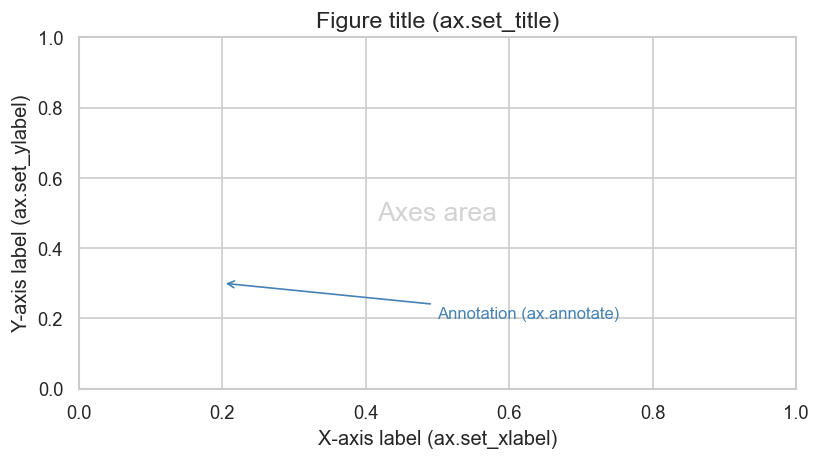

In [8]:

import numpy as np

import pandas as pd

import matplotlib.pyplot as plt

import seaborn as sns


# Notebook display settings

%matplotlib inline

plt.rcParams['figure.dpi'] = 120

sns.set_theme(style='whitegrid', palette='muted')



# Load dataset

df = sns.load_dataset('titanic').dropna(subset=['age', 'embarked'])

df['age_group'] = pd.cut(df['age'], bins=[0,12,18,35,60,120],
labels=['Child','Teen','Young Adult','Adult','Senior'])

print('Dataset shape:', df.shape)


# Anatomy demo — labelled blank figure fig,... by Rajat Garg


# Anatomy demo — labelled blank figure

fig, ax = plt.subplots(figsize=(7, 4))



ax.set_title('Figure title (ax.set_title)', fontsize=14)

ax.set_xlabel('X-axis label (ax.set_xlabel)')

ax.set_ylabel('Y-axis label (ax.set_ylabel)')

ax.text(0.5, 0.5, 'Axes area', transform=ax.transAxes,

ha='center', va='center', fontsize=16, color='lightgray')



# Annotation arrow

ax.annotate('Annotation (ax.annotate)',

xy=(0.2, 0.3), xycoords='axes fraction',

 xytext=(0.5, 0.2), textcoords='axes fraction',

arrowprops=dict(arrowstyle='->', color='steelblue'),

color='steelblue', fontsize=10)


plt.tight_layout()

plt.show()



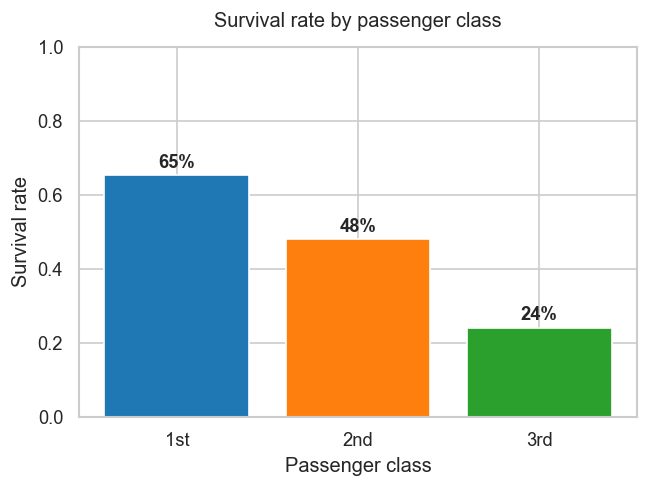

In [9]:
survival_by_class = df.groupby('pclass')['survived'].mean().reset_index()
survival_by_class.columns = ['Class', 'Survival Rate']
survival_by_class['Class'] = survival_by_class['Class'].map({1:'1st', 2: '2nd',
                                                             3: '3rd'})
 
fig, ax = plt.subplots(figsize=(6,4))
 
bars = ax.bar(survival_by_class['Class'], survival_by_class['Survival Rate'],
             color=['tab:blue', 'tab:orange', 'tab:green'])
 
# Add data labels on top of each bar
for bar, val in zip(bars, survival_by_class['Survival Rate']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.0%}', ha='center', va='bottom', fontsize=11, fontweight='bold')
 
ax.set_title('Survival rate by passenger class', pad=12)
ax.set_xlabel('Passenger class')
ax.set_ylabel('Survival rate')
ax.set_ylim(0, 1)
 
plt.show()

<Axes: xlabel='pclass', ylabel='survived'>

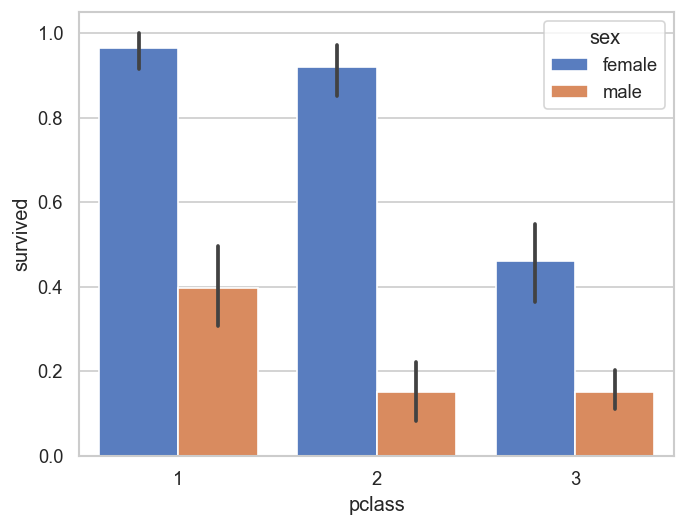

In [10]:
sns.barplot(data=df, x='pclass', y='survived', hue='sex')

C:\Users\SH173SF\AppData\Local\Temp\ipykernel_2548\486707202.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='Class')


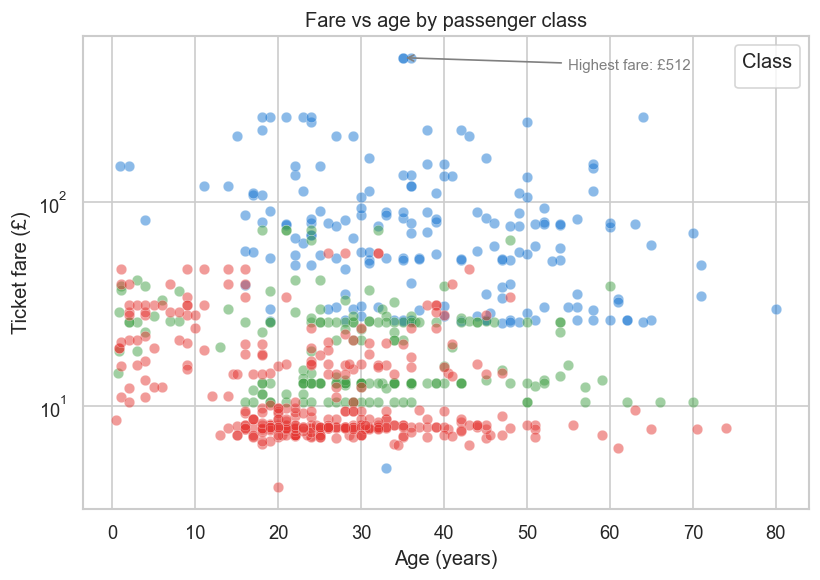

In [12]:
fig, ax = plt.subplots(figsize=(7, 5))


colors = {1: '#1976D2', 2: '#43A047', 3: '#E53935'}

labels = {1: '1st class', 2: '2nd class', 3: '3rd class'}


for cls in [1, 2, 3]:

    subset = df[df['pclass'] == cls]

    ax.scatter(subset['age'], subset['fare'],

    c=colors[cls],alpha=0.5, s=40, edgecolors='white', linewidth=0.3)

ax.set_title('Fare vs age by passenger class')

ax.set_xlabel('Age (years)')

ax.set_ylabel('Ticket fare (£)')

ax.legend(title='Class')

ax.set_yscale('log') 

# Annotate an outlier

max_fare_idx = df['fare'].idxmax()

ax.annotate(f"Highest fare: £{df.loc[max_fare_idx, 'fare']:.0f}",
            xy=(df.loc[max_fare_idx, 'age'], df.loc[max_fare_idx, 'fare']),

            xytext=(55, 450), arrowprops=dict(arrowstyle='->', color='gray'),

            fontsize=9, color='gray')


plt.tight_layout()

plt.show()

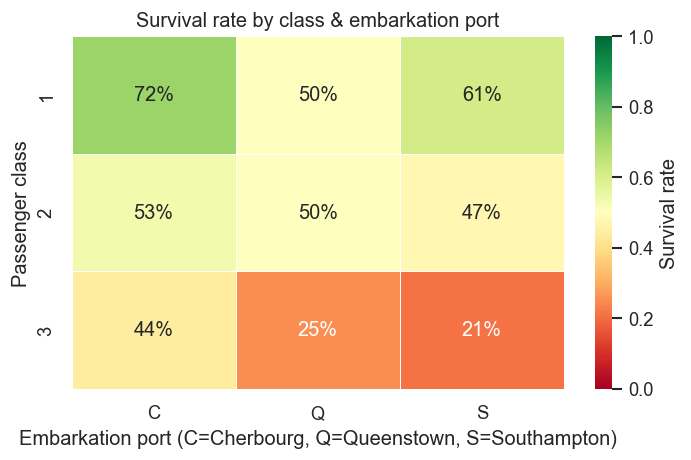

In [13]:
pivot = df.pivot_table(values='survived', index='pclass', columns='embarked', aggfunc='mean')
 
fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(pivot, annot=True, fmt='.0%', cmap='RdYlGn',
            linewidths=0.5, ax=ax, vmin=0, vmax=1,
            cbar_kws={'label': 'Survival rate'})
 
ax.set_title('Survival rate by class & embarkation port')
ax.set_xlabel('Embarkation port (C=Cherbourg, Q=Queenstown, S=Southampton)')
ax.set_ylabel('Passenger class')
 
plt.tight_layout()
plt.show()

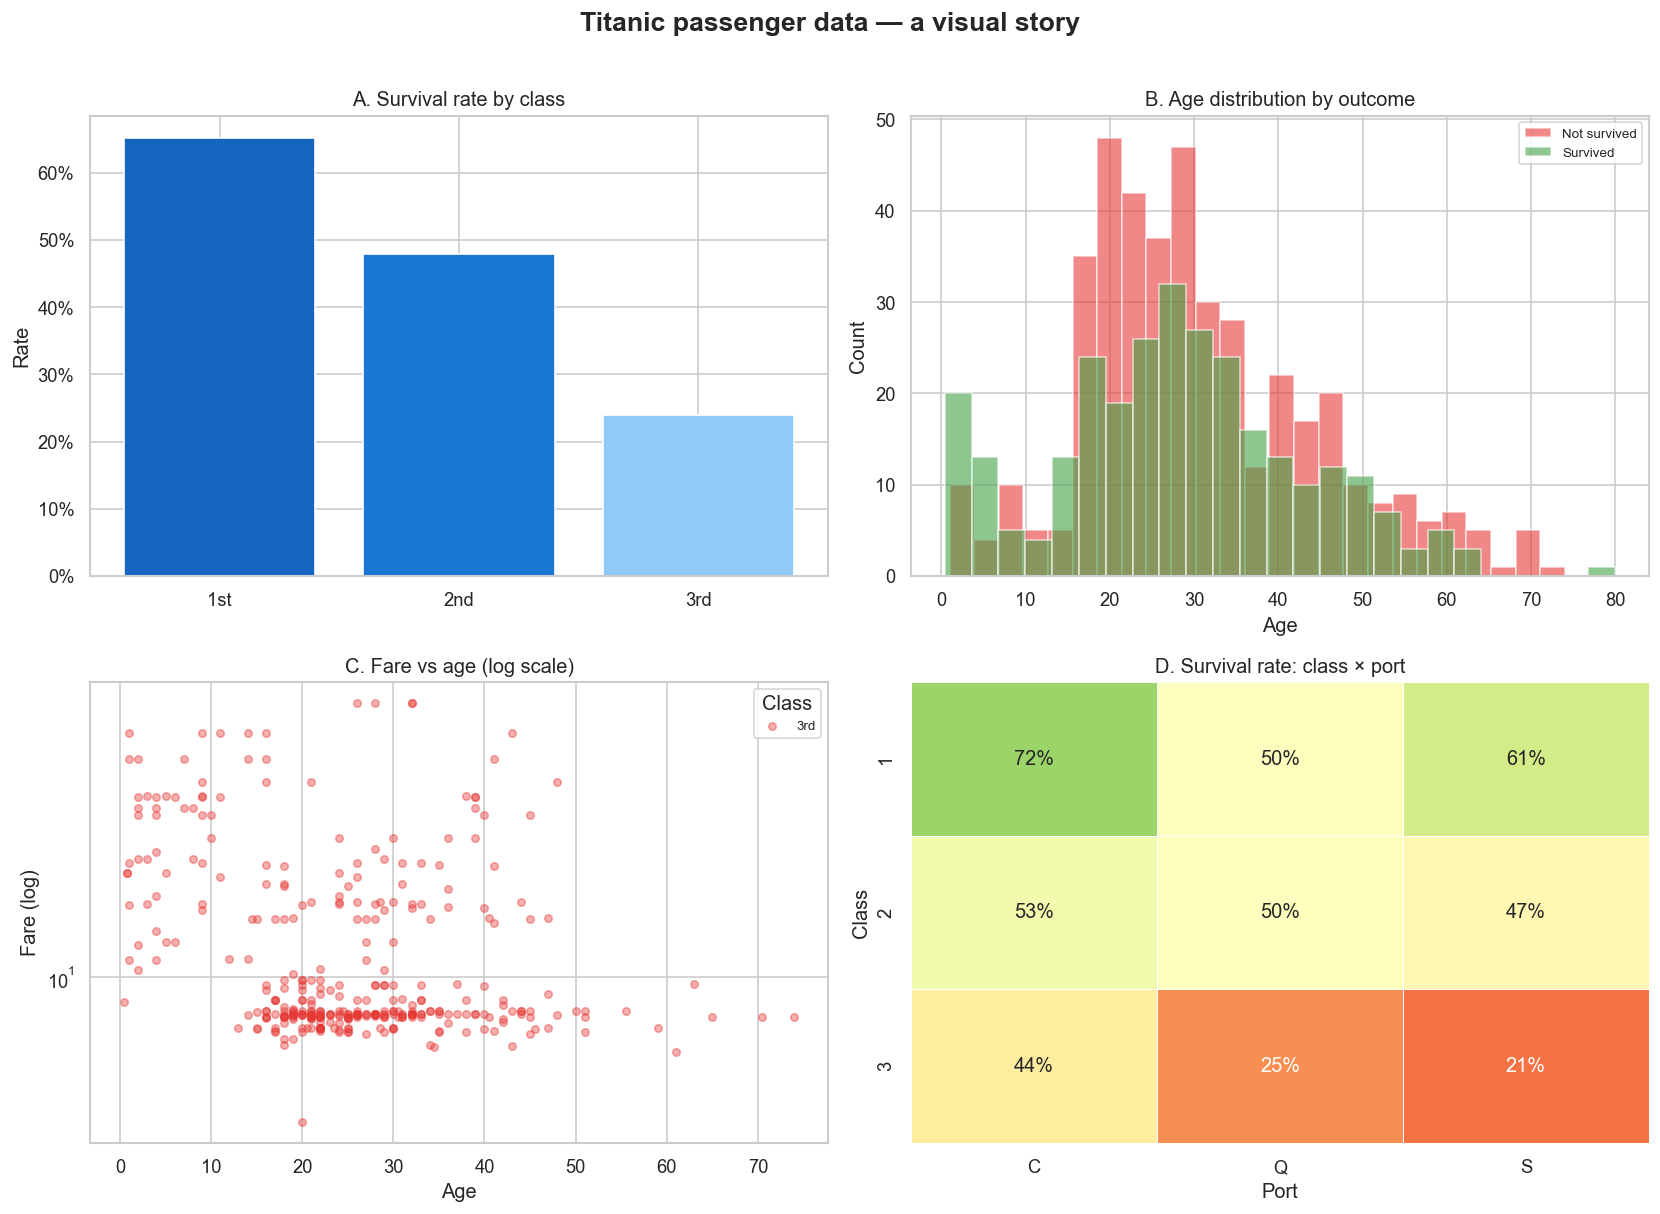

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

fig.suptitle('Titanic passenger data — a visual story', fontsize=16, fontweight='bold', y=1.01)
ax = axes[0, 0]

surv = df.groupby('pclass')['survived'].mean()

ax.bar(['1st','2nd','3rd'], surv.values, color=['#1565C0','#1976D2','#90CAF9'])

ax.set_title('A. Survival rate by class')

ax.set_ylabel('Rate')

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y,_: f'{y:.0%}'))

# ── Panel B: age histogram ──

ax = axes[0, 1]

ax.hist(df[df['survived']==0]['age'], bins=25, alpha=0.6, color='#E53935', label='Not survived')

ax.hist(df[df['survived']==1]['age'], bins=25, alpha=0.6, color='#43A047', label='Survived')

ax.set_title('B. Age distribution by outcome')

ax.set_xlabel('Age')

ax.set_ylabel('Count')

ax.legend(fontsize=8)

# ── Panel C: fare vs age scatter ──

ax = axes[1, 0]

for cls, c, lbl in zip([1,2,3],['#1976D2','#43A047','#E53935'],['1st','2nd','3rd']):

    s = df[df['pclass']==cls]

ax.scatter(s['age'], s['fare'], c=c, alpha=0.4, s=20, label=lbl)

ax.set_yscale('log')

ax.set_title('C. Fare vs age (log scale)')

ax.set_xlabel('Age')

ax.set_ylabel('Fare (log)')

ax.legend(title='Class', fontsize=8)


# ── Panel D: survival heatmap ──

ax = axes[1, 1]

pivot = df.pivot_table(values='survived', index='pclass', columns='embarked', aggfunc='mean')

sns.heatmap(pivot, annot=True, fmt='.0%', cmap='RdYlGn',

linewidths=0.5, ax=ax, vmin=0, vmax=1, cbar=False)

ax.set_title('D. Survival rate: class × port')

ax.set_xlabel('Port')

ax.set_ylabel('Class')

plt.tight_layout()

plt.show()

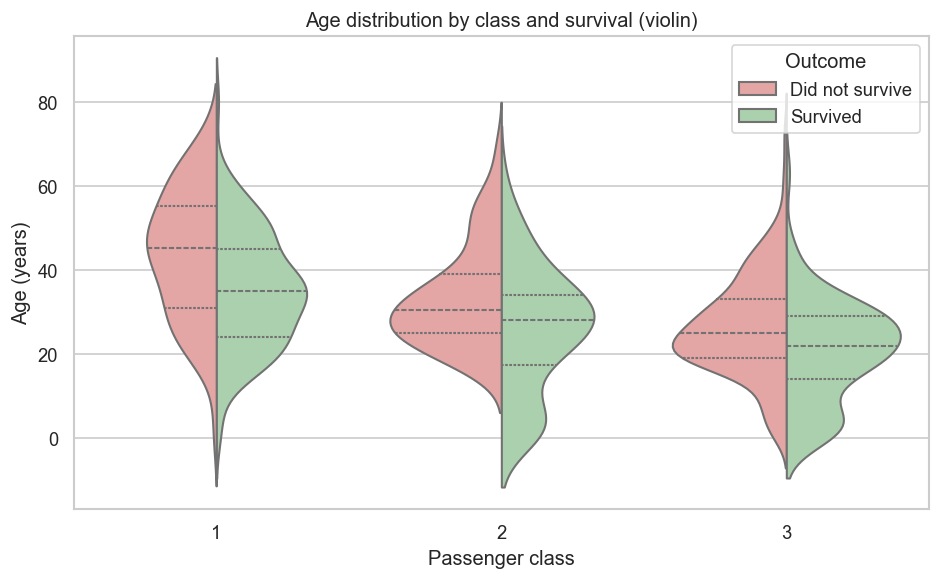

In [18]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.violinplot(data=df, x='pclass', y='age', hue='survived',

split=True, palette={0:'#EF9A9A', 1:'#A5D6A7'},

inner='quartile', ax=ax)

ax.set_title('Age distribution by class and survival (violin)')

ax.set_xlabel('Passenger class')

ax.set_ylabel('Age (years)')

handles, _ = ax.get_legend_handles_labels()

ax.legend(handles, ['Did not survive', 'Survived'], title='Outcome')

plt.tight_layout()

plt.show()

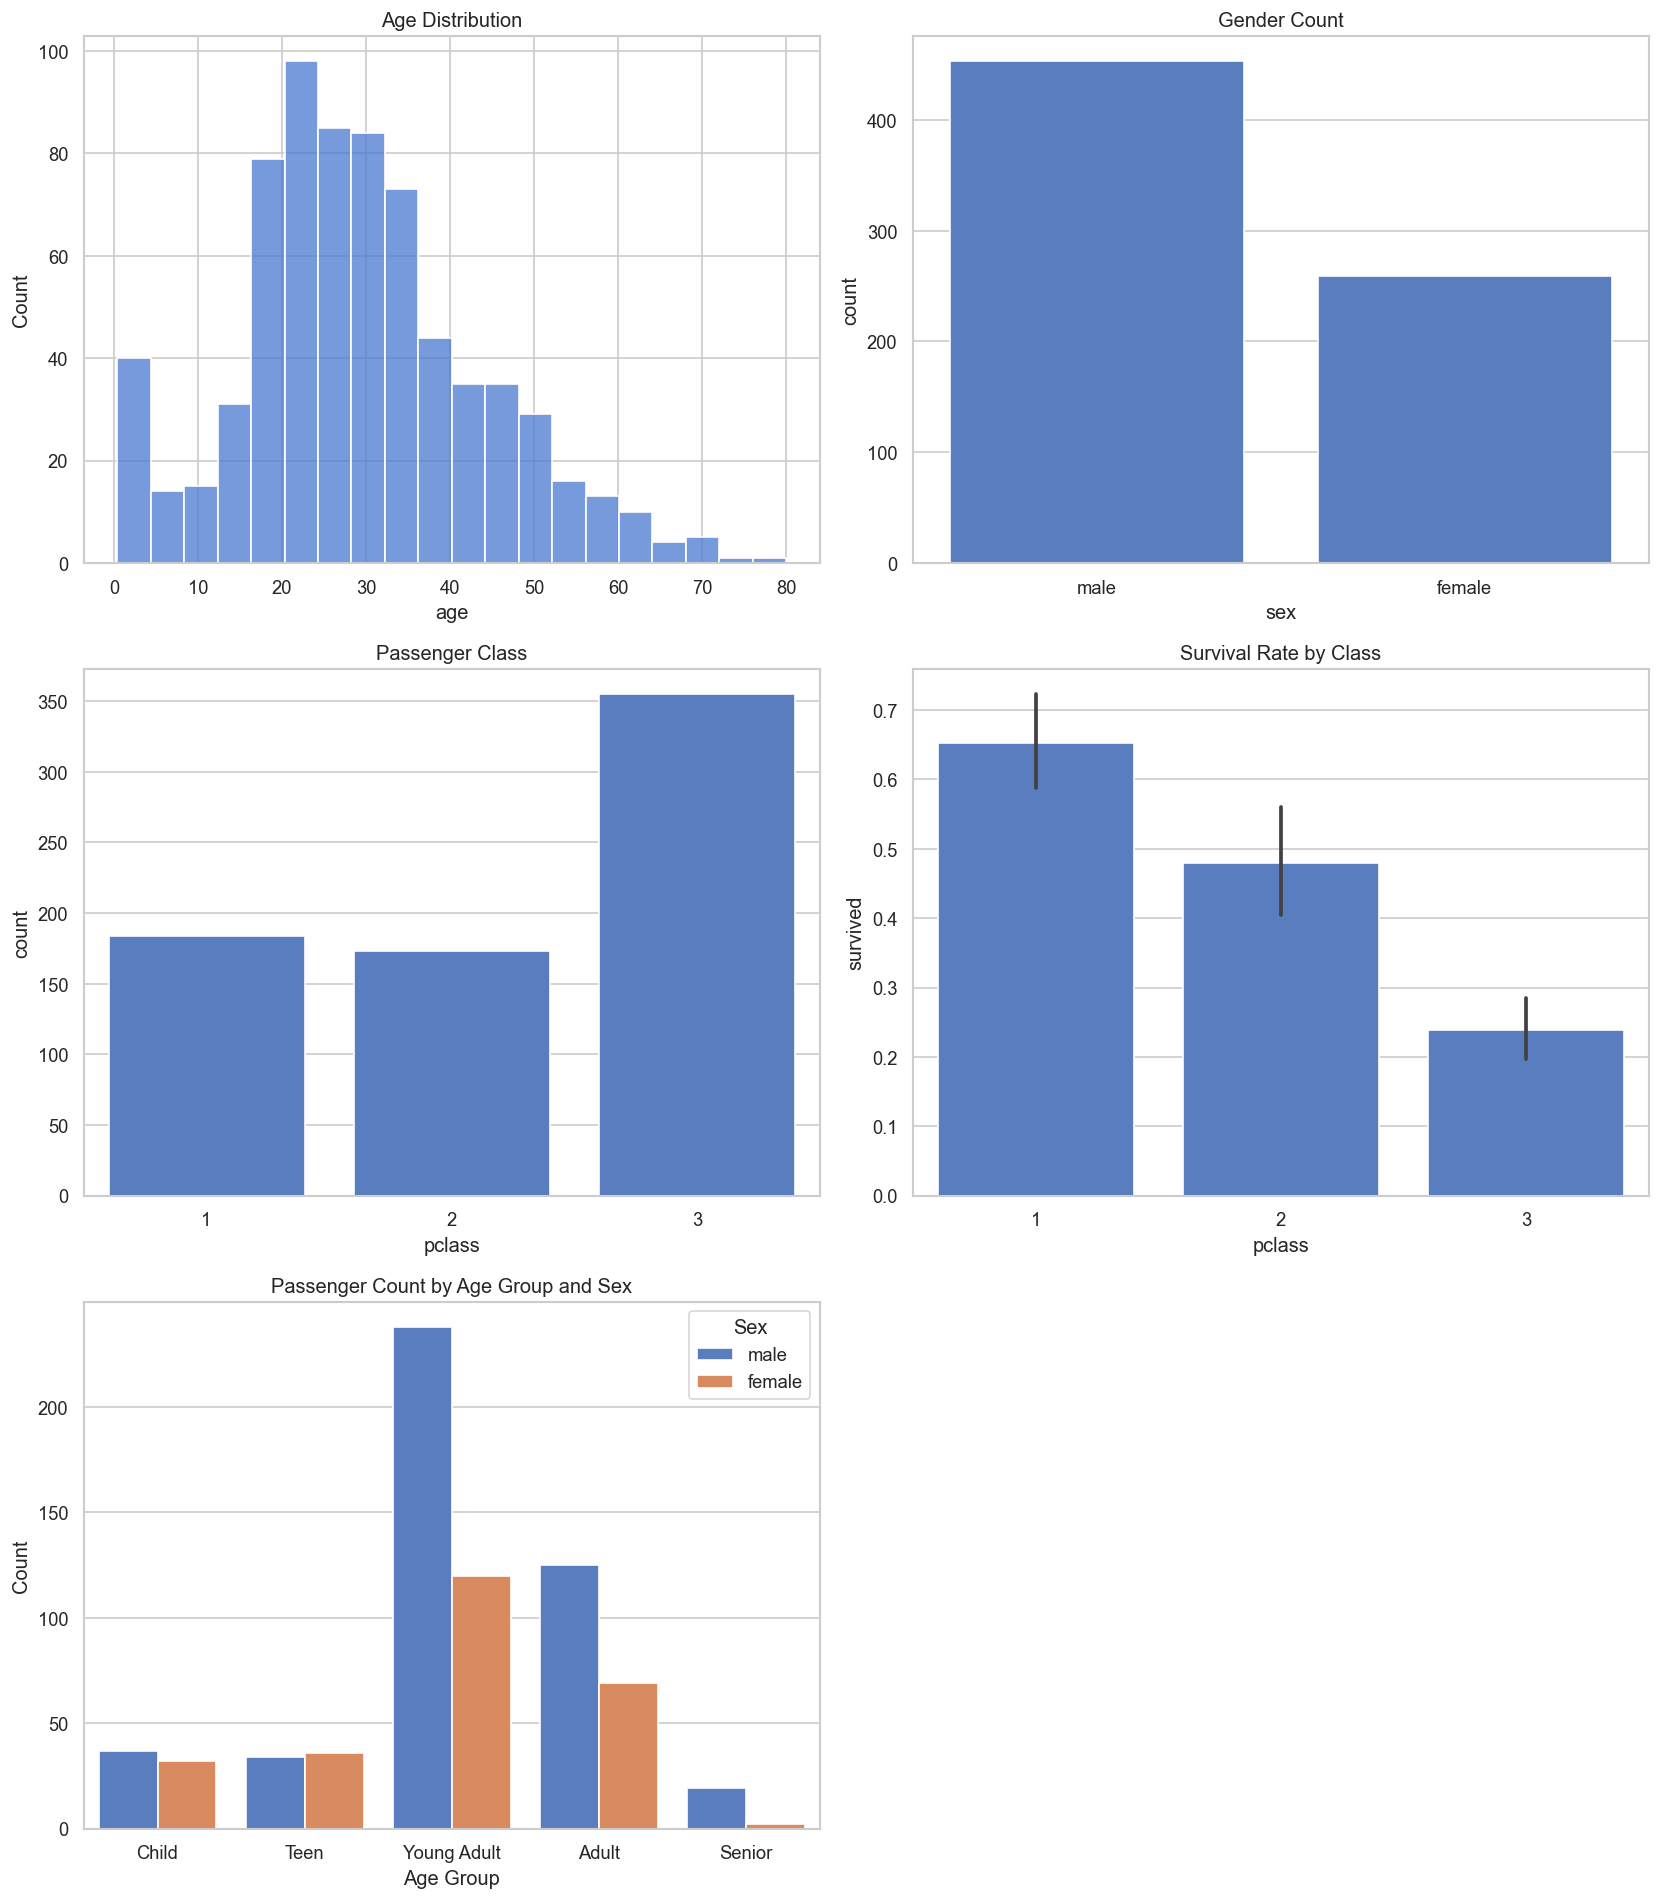

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming your dataframe is called df and already contains 'age_group' and 'sex'

# Create 5 subplots
fig, axes = plt.subplots(3, 2, figsize=(14, 16))  # 3x2 grid (last one empty if needed)
axes = axes.flatten()

# Panel 1–4: your existing plots here
# Example placeholders (replace with your actual plots)
sns.histplot(df['age'].dropna(), ax=axes[0])
axes[0].set_title('Age Distribution')

sns.countplot(x='sex', data=df, ax=axes[1])
axes[1].set_title('Gender Count')

sns.countplot(x='pclass', data=df, ax=axes[2])
axes[2].set_title('Passenger Class')

sns.barplot(x='pclass', y='survived', data=df, ax=axes[3])
axes[3].set_title('Survival Rate by Class')

# ✅ Panel 5: New countplot (age_group vs sex)
sns.countplot(data=df, x='age_group', hue='sex', ax=axes[4])
axes[4].set_title('Passenger Count by Age Group and Sex')
axes[4].set_xlabel('Age Group')
axes[4].set_ylabel('Count')
axes[4].legend(title='Sex')

# Optional: hide the unused 6th subplot
fig.delaxes(axes[5])

# Adjust layout
plt.tight_layout()

# Save figure
plt.savefig('titanic_dashboard.png', dpi=300, bbox_inches='tight')

# Show plot
plt.show()